# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [ ]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [2]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
file_1 = 'https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input'

In [4]:
## TODO : make into a dataframe called df
df = pd.read_csv("Churn_Modelling.csv")

In [5]:
## TODO : output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

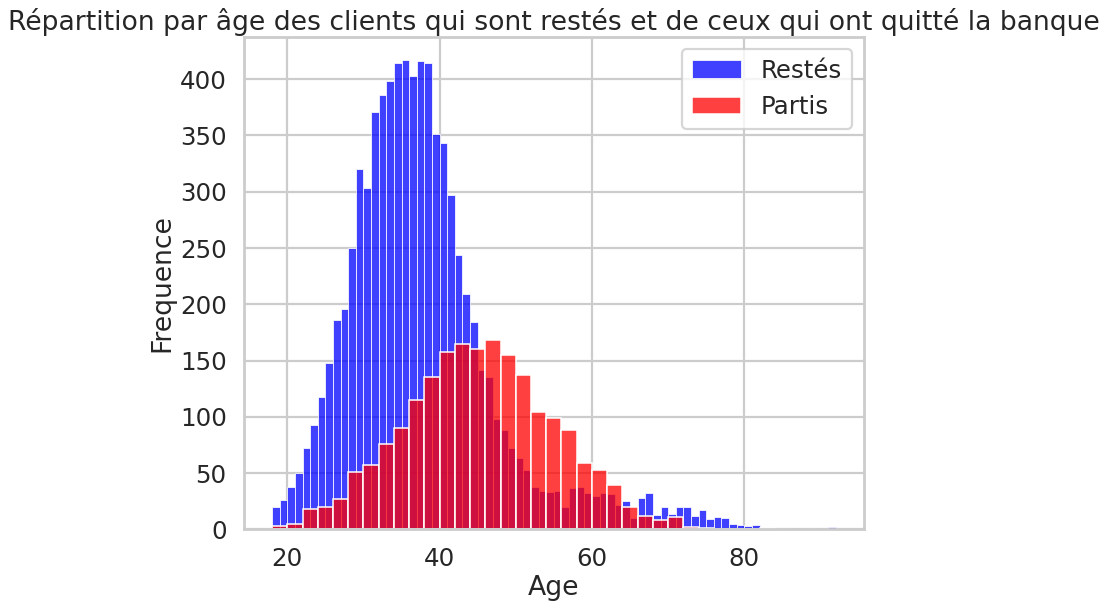

In [38]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
plt.figure(figsize=(10, 8),dpi=80)
sns.histplot(df_0['Age'], color='blue', label='Restés')
sns.histplot(df_1['Age'], color='red', label='Partis')
plt.title('Répartition par âge des clients qui sont restés et de ceux qui ont quitté la banque')
plt.xlabel('Age')
plt.ylabel('Frequence')
plt.legend()
plt.show()

In [39]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
print("Âge moyen des clients restés fidèles à la banque :", df_0['Age'].mean())
print("Écart type de l'âge des clients restés fidèles à la banque :", df_0['Age'].std())

Âge moyen des clients restés fidèles à la banque : 37.40838879819164
Écart type de l'âge des clients restés fidèles à la banque : 10.125362911047631


In [40]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.
print("Âge moyen des clients ayant quitté la banque :", df_1['Age'].mean())
print("Écart type de l'âge des clients ayant quitté la banque :", df_1['Age'].std())

Âge moyen des clients ayant quitté la banque : 44.8379970544919
Écart type de l'âge des clients ayant quitté la banque : 9.761561555507132


H0 : La moyenne des ages des clients ayant quitter la banque et ceux qui sont restés sont égales.  
H1 : Ils existes une différence significative entre la moyenne des âge des personnes qui ont quitté la banque et ceux qui sont restés

In [41]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.

t_statistic, p_value = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'])
print("t-statistic:", t_statistic)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Rejet de l'hypothèse nulle")
    print("Les âges des clients qui sont restés et de ceux qui ont quitté la banque ne sont pas similaires.")
else:
    print("Echec de rejet de l'hypothèse nulle")
    print("L'âge des clients qui sont restés et de ceux qui ont quitté la banque est similaire.")

t-statistic: -29.76681499437077
p-value: 1.2399313093427736e-186
Rejet de l'hypothèse nulle
Les âges des clients qui sont restés et de ceux qui ont quitté la banque ne sont pas similaires.


### Using Bootstrapping

In [19]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc)
    return bs_s

In [20]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
diff_means = df_0['Age'].mean() - df_1['Age'].mean()
overall_mean = df['Age'].mean()

In [21]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
bs_size = 1000
bs_means_0 = bs_choice(df_0['Age'], np.mean, bs_size)
bs_means_1 = bs_choice(df_1['Age'], np.mean, bs_size)

In [22]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
p_value = np.sum(np.abs(bs_means_0 - bs_means_1) >= np.abs(diff_means)) / bs_size
print("p-value:", p_value)

p-value: 0.531


### Conclusion
Je ne rejette pas l'hypothèse nulle car p-value > 0.05

## Hypothesis 2: Credit Score

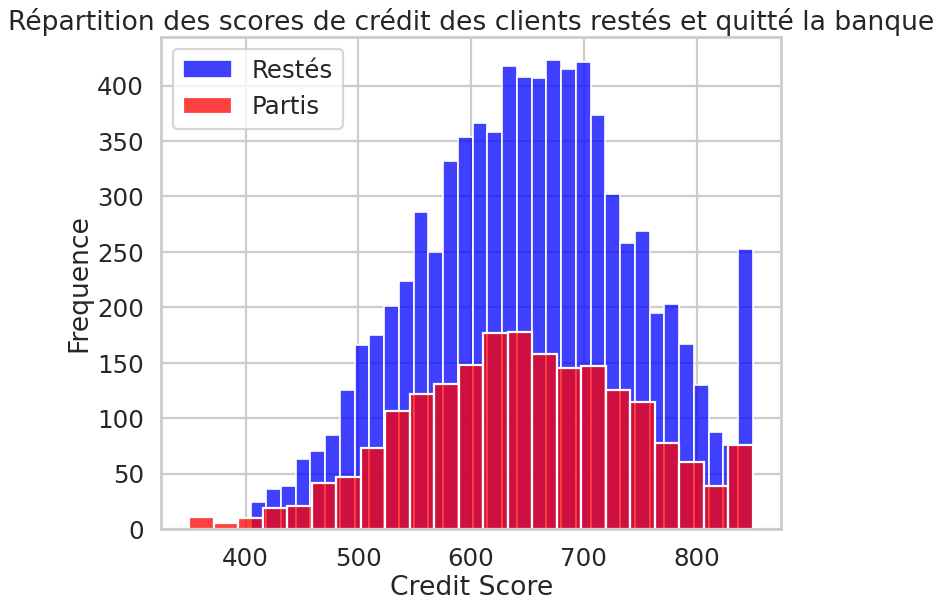

In [46]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
plt.figure(figsize=(10, 8),dpi=80)
sns.histplot(df_0['CreditScore'], color='blue', label='Restés')
sns.histplot(df_1['CreditScore'], color='red', label='Partis')
plt.title('Répartition des scores de crédit des clients restés et quitté la banque')
plt.xlabel('Credit Score')
plt.ylabel('Frequence')
plt.legend()
plt.show()

H0 : La moyenne des crédits scores des deux groupes sont similaires.  
H1 : La moyenne des crédits scores des deux groupes sont différents

In [43]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).
t_statistic, p_value = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'])
print("t-statistic:", t_statistic)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Rejet de l'hypothèse nulle")
    print("Les scores de crédit des clients restés et des clients partis de la banque ne sont pas similaires.")
else:
    print("Echec rejet de l'hypothèse nulle")
    print("Les scores de crédit des clients restés et des clients partis de la banque sont similaires.")

t-statistic: 2.7100778888729833
p-value: 0.006738213892192373
Rejet de l'hypothèse nulle
Les scores de crédit des clients restés et des clients partis de la banque ne sont pas similaires.


### Conclusion
On rejette l'hypothèse nulle car p-value < 0.05

## Hypothesis 3: Balance

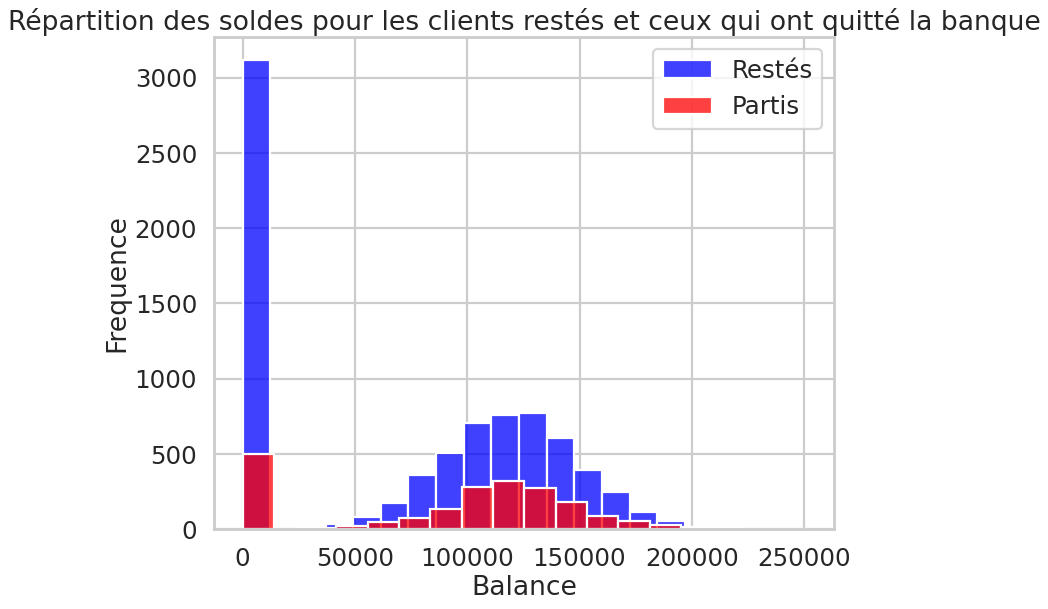

In [45]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).
plt.figure(figsize=(10, 8),dpi=80)
sns.histplot(df_0['Balance'], color='blue', label='Restés')
sns.histplot(df_1['Balance'], color='red', label='Partis')
plt.title('Répartition des soldes pour les clients restés et ceux qui ont quitté la banque')
plt.xlabel('Balance')
plt.ylabel('Frequence')
plt.legend()
plt.show()

H0 : La moyenne des balances des deux groupes sont similaires  
H1 : La moyenne des balances des deux groupes sont différents

In [47]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
t_statistic, p_value = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'])
print("t-statistic:", t_statistic)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Rejet de l'hypothèse nulle")
    print("Les balances des clients restés et de ceux qui ont quitté la banque ne sont pas similaires.")
else:
    print("Echec rejet de l'hypothèse nulle")
    print("Les balances des clients restés et de ceux qui ont quitté la banque sont similaires.")

t-statistic: -11.936240300013841
p-value: 1.2755633191525477e-32
Rejet de l'hypothèse nulle
Les balances des clients restés et de ceux qui ont quitté la banque ne sont pas similaires.


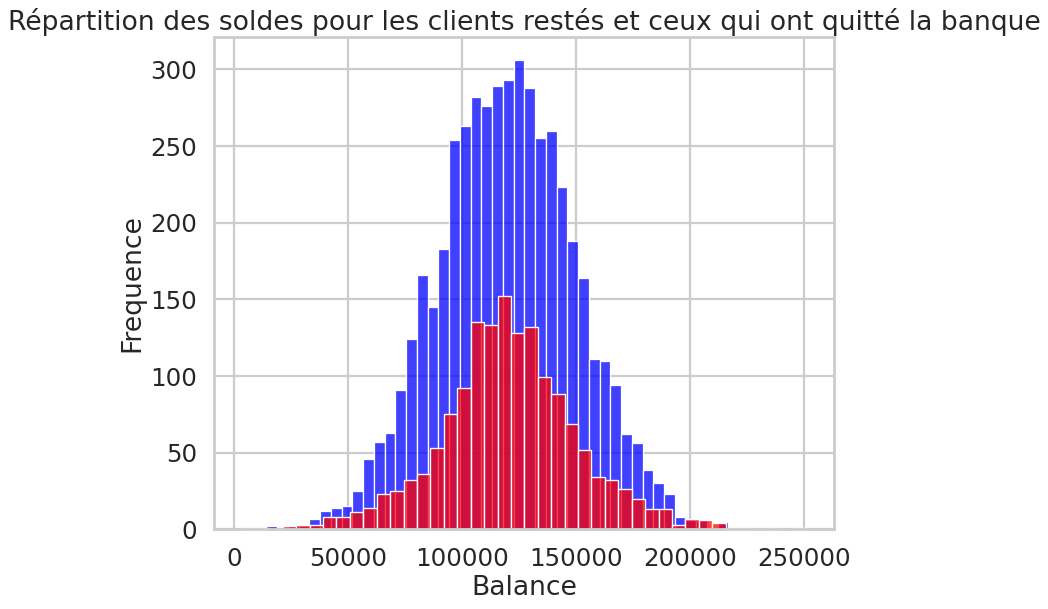

In [48]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
plt.figure(figsize=(10, 8),dpi=80)
sns.histplot(df_0[df_0['Balance'] > 0]['Balance'], color='blue', label='Restés')
sns.histplot(df_1[df_1['Balance'] > 0]['Balance'], color='red', label='Partis')
plt.title('Répartition des soldes pour les clients restés et ceux qui ont quitté la banque')
plt.xlabel('Balance')
plt.ylabel('Frequence')
plt.show()

In [49]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.
t_statistic, p_value = scipy.stats.ttest_ind(df_0[df_0['Balance'] > 0]['Balance'], df_1[df_1['Balance'] > 0]['Balance'])
print("t-statistic:", t_statistic)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Rejet de l'hypothèse nulle")
    print("Les balances des clients restés et de ceux qui ont quitté la banque ne sont pas similaires.")
else:
    print("Echec rejet de l'hypothèse nulle")
    print("Les balances des clients restés et de ceux qui ont quitté la banque sont similaires.")

t-statistic: -1.374781881782122
p-value: 0.16924734893322796
Echec rejet de l'hypothèse nulle
Les balances des clients restés et de ceux qui ont quitté la banque sont similaires.


## Conclusion

On rejette l'hypothèse H1 car p-value > 0.05, il n'existe pas de différence significative entre la moyenne des sommes contenues dans le portefeuille des deux groupes

## Hypothesis 4: Estimated Salary

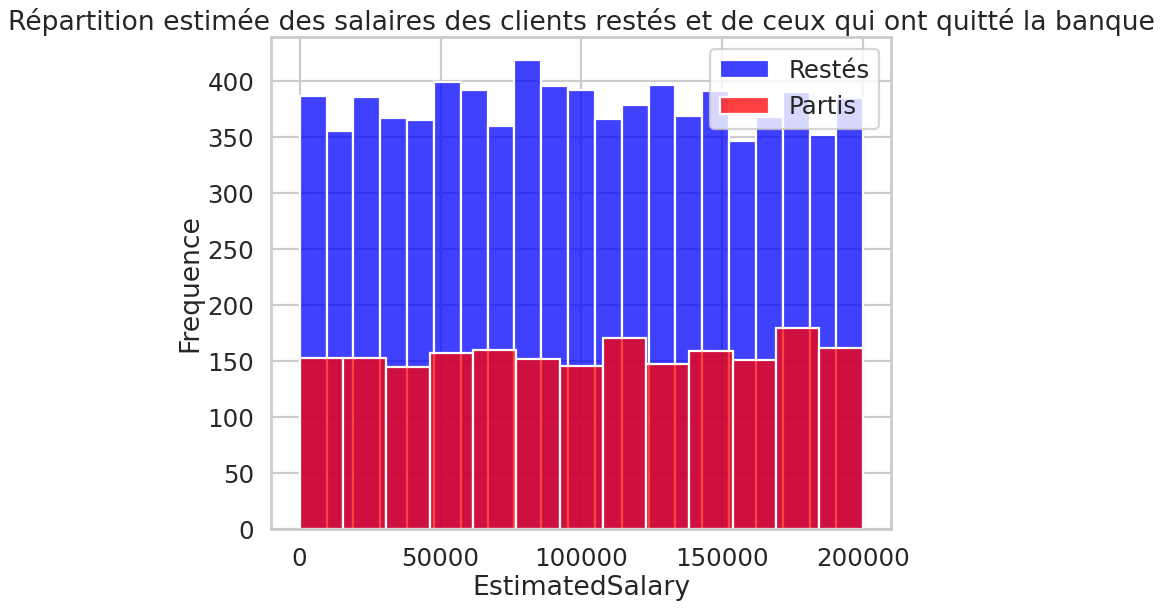

In [50]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
plt.figure(figsize=(10, 8),dpi=80)
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Restés')
sns.histplot(df_1['EstimatedSalary'], color='red', label='Partis')
plt.title('Répartition estimée des salaires des clients restés et de ceux qui ont quitté la banque')
plt.xlabel('EstimatedSalary')
plt.ylabel('Frequence')
plt.legend()
plt.show()

H0 : Le salaire estimé des deux groupes sont simaires.   
H1 : Le salaire estimé des deux groupes sont différents.   

In [51]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
t_statistic, p_value = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])
print("t-statistic:", t_statistic)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Rejet de l'hypothèse nulle")
    print("Les salaires estimés des clients restés et de ceux qui ont quitté la banque ne sont pas similaires.")
else:
    print("Echec rejet de l'hypothèse nulle")
    print("Les salaires estimés des clients restés et de ceux qui ont quitté la banque sont similaires.")

t-statistic: -1.209653638019264
p-value: 0.22644042802223352
Echec rejet de l'hypothèse nulle
Les salaires estimés des clients restés et de ceux qui ont quitté la banque sont similaires.


### Using Bootstrapping

In [34]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.
diff_means = df_0['EstimatedSalary'].mean() - df_1['EstimatedSalary'].mean()
overall_mean = df['EstimatedSalary'].mean()

In [35]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.
bs_size = 1000
bs_means_0 = bs_choice(df_0['EstimatedSalary'], np.mean, bs_size)
bs_means_1 = bs_choice(df_1['EstimatedSalary'], np.mean, bs_size)

In [36]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.
p_value = np.sum(np.abs(bs_means_0 - bs_means_1) >= np.abs(diff_means)) / bs_size
print("p-value:", p_value)

p-value: 0.48


### Conclusion
On garde l'hypothèse nulle car p-value > 0.05

## Final Conclusion
What will be the most helpful feature in predicting churning?


D'après les tests d'hypothèses effectués, voici un résumé des résultats concernant le taux de désabonnement des clients :

**Âge**:

Le test t a révélé une différence d'âge significative entre les clients restés et ceux qui sont partis (p = 1,24e-186), rejetant ainsi l'hypothèse nulle d'une similarité d'âge.

Cependant, l'analyse par bootstrap de l'âge n'a pas permis de rejeter l'hypothèse nulle (p = 0,531), suggérant une similarité.

**Score de crédit**:

Le test t et sa conclusion ont clairement rejeté l'hypothèse nulle (p = 0,0067), indiquant que les scores de crédit des clients restés et de ceux qui sont partis ne sont pas similaires.

**Solde**:

En considérant tous les soldes, le test t a rejeté l'hypothèse nulle (p = 1,28e-32), suggérant une différence. Cependant, en excluant les soldes nuls, le test t n'a pas permis de rejeter l'hypothèse nulle (p-valeur : 0,169), concluant que les soldes des clients restés et de ceux ayant quitté la banque sont similaires. La conclusion du document indique : « On rejette l'hypothèse H1 car p-valeur > 0,05 », ce qui confirme l'acceptation de l'hypothèse nulle de similarité en excluant les soldes nuls.

**Salaire estimé**:

Ni le test t (p-valeur : 0,226), ni l'analyse par bootstrap (p-valeur : 0,48) n'ont permis de rejeter l'hypothèse nulle, concluant que les salaires estimés des clients restés et de ceux ayant quitté la banque sont similaires.

Au vu de ces résultats, les facteurs les plus pertinents pour prédire le taux de rotation des clients seraient l'âge (d'après le test t) et le score de crédit, car ils présentent des différences significatives entre les deux groupes. Le solde (en particulier en incluant les soldes nuls) semble également être un prédicteur fiable, bien que la conclusion concernant les soldes non nuls suggère une similarité. Le salaire estimé ne semble pas être un facteur de différenciation.